<a href="https://colab.research.google.com/github/gaga0321/scRNA-aging-analysis/blob/main/scRNA_aging_analysis_spleen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install scanpy
import scanpy as sc
adata_aging = sc.read_h5ad("tabula-muris-senis-facs-processed-official-annotations-Spleen.h5ad")
print(list(adata_aging.obs.columns))

['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden']


/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


Ages in this cohort: ['18m', '24m', '3m']

Top 5 cell types found in this tissue:
cell_ontology_class
B cell                             2851
CD4-positive, alpha-beta T cell     414
CD8-positive, alpha-beta T cell     354
proerythroblast                     107
NK cell                              87
Name: count, dtype: int64


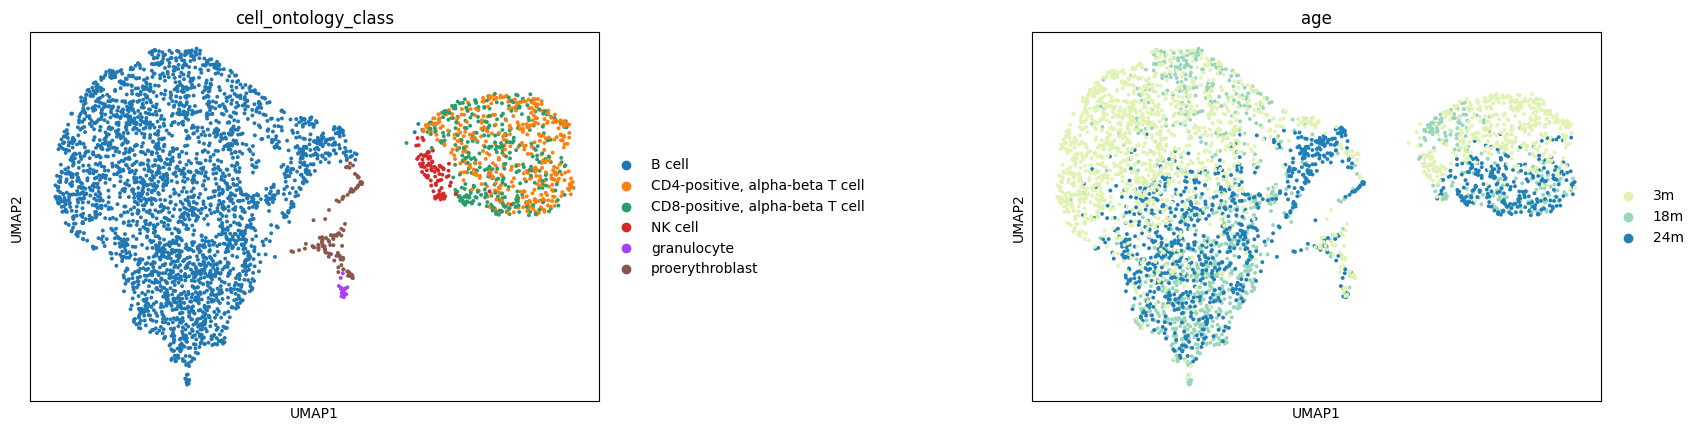

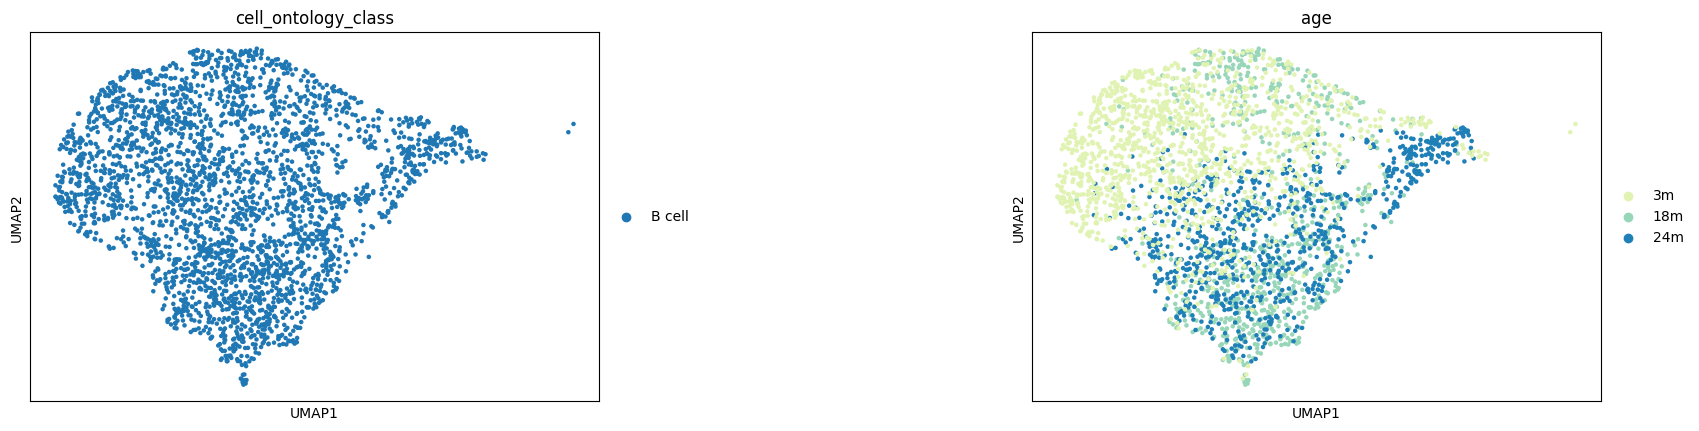

In [5]:
print("Ages in this cohort:", adata_aging.obs['age'].unique().tolist())
print("\nTop 5 cell types found in this tissue:")
print(adata_aging.obs['cell_ontology_class'].value_counts().head(5))
sc.pl.umap(adata_aging, color=['cell_ontology_class', 'age'], wspace=0.6)
B_cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'B cell'].copy()
sc.pl.umap(B_cells, color=['cell_ontology_class', 'age'], wspace=0.6)

Top Upregulated B cell Drivers (Ranked by Fold Change):
       18m_n     18m_l          18m_p
0     Tmsb10  2.948224  9.636958e-289
1      Snrpc  2.499741   8.490544e-08
2       Cfl1  1.922906  4.033167e-202
3      Tomm6  1.715040   3.275881e-32
4       Jund  1.680943   8.725911e-50
5        Fos  1.672555   4.398810e-06
6     Rpl13a  1.596439  5.371354e-178
7        Aes  1.578456   5.181273e-33
8      Sf3b4  1.519244   6.006868e-10
9      Prr13  1.429152   2.333362e-28
10  Npm3-ps1  1.397009   4.629237e-06
11     Kdm6b  1.385355   2.224364e-09
12      Pfn1  1.344650  7.265540e-109
13    Scand1  1.303771   9.281189e-14
14     Cotl1  1.285347   2.746940e-43
15     Sepw1  1.248696   8.916920e-37
16     Zfp36  1.144962   1.510156e-19
17     Rpl13  1.124686   2.467367e-86
18       B2m  1.118673   3.338243e-82
19       Ltb  1.098416   7.782949e-57


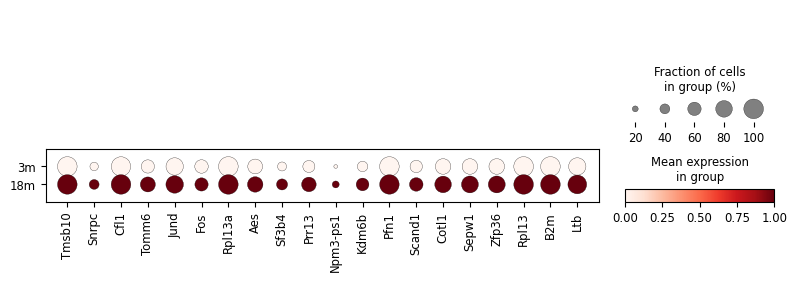

Top Downregulated B cell Targets (Ranked by Fold Change):
      18m_n     18m_l         18m_p
0      Plp1 -4.119914  1.582607e-22
1      Krt8 -3.685878  1.348938e-16
2      Lyz2 -3.147640  2.614172e-21
3       Trf -2.790106  3.427813e-30
4      Cd36 -1.929880  2.581728e-06
5     Lars2 -1.865545  9.755916e-66
6   Serinc3 -1.755798  1.614373e-61
7    Map3k1 -1.672802  1.754261e-35
8     Acta2 -1.588771  5.466276e-09
9     Krt18 -1.571114  4.949129e-06
10  Zfp36l2 -1.425595  1.117529e-20
11  Fam107b -1.382739  2.858969e-10
12      Mgp -1.252900  2.364455e-09
13    Txnip -1.234362  1.522977e-13
14    Sesn1 -1.158604  7.971000e-09
15   Lrrc58 -1.151695  8.300296e-13
16   Atp2a3 -1.138767  1.752869e-08
17  Tmem123 -1.075963  1.338684e-06
18   Igfbp7 -1.025122  4.085456e-07
19     Brd2 -1.011401  5.789132e-08


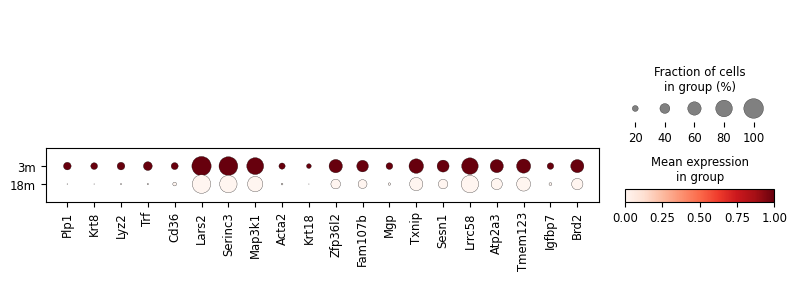

In [8]:
import pandas as pd
sc.tl.rank_genes_groups(
    B_cells,
    groupby='age',
    groups=['18m'],
    reference='3m',
    method='wilcoxon',
    use_raw=False
)
result = B_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.5) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 1e-5].sort_values(by='18m_l', ascending=False).reset_index(drop=True)
print("Top Upregulated B cell Drivers (Ranked by Fold Change):")
print(final_up_df[['18m_n', '18m_l', '18m_p']].head(20))
top_genes = final_up_df['18m_n'].head(20).tolist()
subset = B_cells[B_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

downregulated_genes = dataframe[
    (dataframe['18m_l'] < -0.5) &
    (dataframe['18m_l'] > -15) &
    (dataframe['18m_l'] != float('-inf'))
]
final_down_df = downregulated_genes[downregulated_genes['18m_p'] < 1e-5].sort_values(by='18m_l', ascending=True).reset_index(drop=True)
print("Top Downregulated B cell Targets (Ranked by Fold Change):")
print(final_down_df[['18m_n', '18m_l', '18m_p']].head(20))
top_down_genes = final_down_df['18m_n'].head(20).tolist()
subset = B_cells[B_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_down_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

Top 10 Upregulated Pathways in Aged B Cells:
                                                Term  Adjusted P-value Overlap
0               Cytoplasmic Translation (GO:0002181)      1.422189e-15  15/101
1    Macromolecule Biosynthetic Process (GO:0009059)      2.011007e-10  14/189
2                           Translation (GO:0006412)      2.181082e-09  14/232
3                       Gene Expression (GO:0010467)      1.160304e-07  15/381
4             Protein Metabolic Process (GO:0019538)      8.393188e-06  16/614
5  Modification-Dependent Macromolecule Catabolic...      1.103094e-03     3/9
6    Ribosomal Small Subunit Biogenesis (GO:0042274)      6.404470e-03    5/85
7  Response to Fibroblast Growth Factor (GO:0071774)      9.203093e-03    3/19
8  Regulation of Nuclear-Transcribed mRNA Catabol...      9.589264e-03    3/20
9  Negative Regulation of Erythrocyte Differentia...      1.356149e-02     2/5


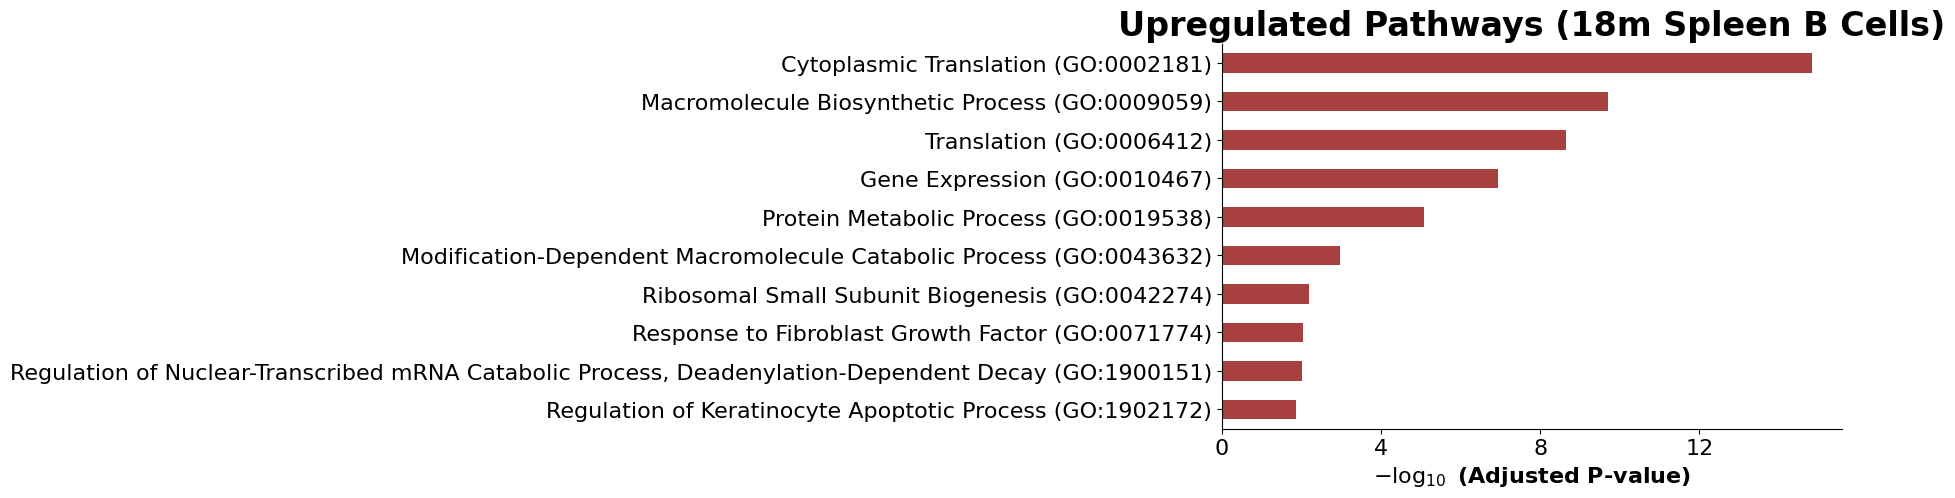

In [9]:
!pip install gseapy
import gseapy as gp
import matplotlib.pyplot as plt
clean_up_genes = final_up_df['18m_n'].head(100).tolist()
enr_up = gp.enrichr(
    gene_list=clean_up_genes,
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
results_up_df = enr_up.results
print("Top 10 Upregulated Pathways in Aged B Cells:")
print(results_up_df[['Term', 'Adjusted P-value', 'Overlap']].head(10))
gp.barplot(
    enr_up.results,
    column="Adjusted P-value",
    title='Upregulated Pathways (18m Spleen B Cells)',
    top_term=10,
    figsize=(8, 5),
    color='darkred'
)
plt.show()